# Track C — VEGAS Falsification (FIXED)
### CS 639 | UW–Madison

---
**Fixes over original:**
- Correct LLM layer path for transformers >=4.45: `model.model.language_model.model.layers`
- VEGAS hook targets LLM **hidden states** correctly (not attention weights, which aren't returned by default)
- Bulk COCO download via zip (fast, single download) with fallback to per-image
- Drive path auto-detection with clear fallback
- Robust `sampled_image_ids.json` support alongside `chair_labels.csv`

**Prediction:** VEGAS reduces CHAIR_I on high-quality (clean) images but has smaller / negative effect on low-quality (hallucinating) images, with Mann-Whitney p < 0.05.


In [ ]:
# Cell 1: Install
!pip install -q transformers==4.37.2 tokenizers==0.15.2 accelerate==0.27.2 \
    Pillow statsmodels scipy matplotlib seaborn sentencepiece protobuf
print('Done. → Runtime → Restart session → then run Cell 2')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.0/280.0 kB 15.1 MB/s eta 0:00:00
Done. → Runtime → Restart session → then run Cell 2


In [ ]:
# ── Cell 2: GPU check + Drive mount ──────────────────────────────────────────
import torch, os, shutil, sys

if not torch.cuda.is_available():
    print('ERROR: No GPU. Set Runtime -> Change runtime type -> H100 (or A100)')
    sys.exit(1)

print(f'GPU: {torch.cuda.get_device_name(0)} | VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

from google.colab import drive
drive.mount('/content/drive')

WORK = '/content/track_c_vegas'
os.makedirs(WORK, exist_ok=True)

# ── Locate Track A Drive folder ───────────────────────────────────────────────
# Try the standard path first; edit DRIVE_TRACKA if your folder is named differently
DRIVE_TRACKA = '/content/drive/MyDrive/CS639_TrackA'
if not os.path.isdir(DRIVE_TRACKA):
    # Try common alternatives
    for alt in ['/content/drive/MyDrive/CS_639_TrackA',
                '/content/drive/MyDrive/CS639',
                '/content/drive/MyDrive/TrackA']:
        if os.path.isdir(alt):
            DRIVE_TRACKA = alt
            break

print(f'Using Drive path: {DRIVE_TRACKA}')

NEEDED = ['rollout_data_complete.npz', 'chair_labels.csv', 'entropy_ranks.csv']
for fname in NEEDED:
    src = f'{DRIVE_TRACKA}/{fname}'
    dst = f'{WORK}/{fname}'
    if not os.path.exists(dst):
        if os.path.exists(src):
            shutil.copy(src, dst)
            print(f'  Copied: {fname}')
        else:
            print(f'  NOT FOUND in Drive: {src}')
            print(f'  -> Upload {fname} manually below or fix DRIVE_TRACKA path')
    else:
        print(f'  Already present: {fname}')

# Optional: sampled_image_ids.json
for fname in ['sampled_image_ids.json']:
    src = f'{DRIVE_TRACKA}/{fname}'
    dst = f'{WORK}/{fname}'
    if not os.path.exists(dst) and os.path.exists(src):
        shutil.copy(src, dst)
        print(f'  Copied: {fname}')

print('\nFiles in WORK:', [f for f in os.listdir(WORK)])

GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition | VRAM: 102.0 GB
Mounted at /content/drive
Using Drive path: /content/drive/MyDrive/CS639_TrackA
  Copied: rollout_data_complete.npz
  Copied: chair_labels.csv
  Copied: entropy_ranks.csv
  Copied: sampled_image_ids.json

Files in WORK: ['rollout_data_complete.npz', 'chair_labels.csv', 'sampled_image_ids.json', 'entropy_ranks.csv']


In [ ]:
# ── Cell 2b: Manual upload fallback (only run if files missing after Cell 2) ──
# Skip this cell if Cell 2 copied everything successfully.
missing = [f for f in ['rollout_data_complete.npz','chair_labels.csv','entropy_ranks.csv']
           if not os.path.exists(f'{WORK}/{f}')]
if missing:
    print(f'Missing: {missing}. Use the file browser or upload here:')
    from google.colab import files
    uploaded = files.upload()
    for fn, data in uploaded.items():
        with open(f'{WORK}/{fn}', 'wb') as f_:
            f_.write(data)
    print('Uploaded:', list(uploaded.keys()))
else:
    print('All required files present — skipping manual upload.')

All required files present — skipping manual upload.


In [ ]:
# ── Cell 3: Load Track A data ─────────────────────────────────────────────────
import numpy as np
import pandas as pd
import json

chair_df   = pd.read_csv(f'{WORK}/chair_labels.csv')
entropy_df = pd.read_csv(f'{WORK}/entropy_ranks.csv')
npz        = np.load(f'{WORK}/rollout_data_complete.npz', allow_pickle=True)

rollout_ids   = npz['image_ids']
rollouts      = npz['rollouts']   # (500, 576)
id_to_rollout = {int(rollout_ids[i]): rollouts[i] for i in range(len(rollout_ids))}

# Use sampled_image_ids.json if present, else fall back to chair_df order
sid_path = f'{WORK}/sampled_image_ids.json'
if os.path.exists(sid_path):
    with open(sid_path) as f:
        ALL_IDS = json.load(f)
    print(f'Loaded {len(ALL_IDS)} image IDs from sampled_image_ids.json')
else:
    ALL_IDS = chair_df['image_id'].tolist()
    print(f'sampled_image_ids.json not found — using chair_df order ({len(ALL_IDS)} images)')

# Quality split (Track B definition):
#   HIGH quality = clean images  (probe acc ~0.964 at layer 18)
#   LOW  quality = hallucinating (probe acc ~0.937 at layer 18)
high_quality_ids = set(chair_df[chair_df['is_hallucinating']==False]['image_id'].values)
low_quality_ids  = set(chair_df[chair_df['is_hallucinating']==True]['image_id'].values)

gt_lookup   = dict(zip(chair_df['image_id'], chair_df['gt_objects']))
hall_lookup = dict(zip(chair_df['image_id'], chair_df['is_hallucinating']))

def parse_gt(s):
    if pd.isna(s): return set()
    return set(str(s).split('|'))

print(f'Total images: {len(chair_df)}')
print(f'High-quality (clean):        {len(high_quality_ids)}')
print(f'Low-quality (hallucinating): {len(low_quality_ids)}')
print(f'Rollouts loaded:             {len(id_to_rollout)}')

Loaded 500 image IDs from sampled_image_ids.json
Total images: 500
High-quality (clean):        171
Low-quality (hallucinating): 329
Rollouts loaded:             500


In [ ]:
# ── Cell 4: Download COCO val2017 images (bulk zip — fast) ────────────────────
# Downloads the full val2017 zip (~1 GB), extracts, then keeps only the 500 needed images.
# Much faster and more reliable than 500 individual urllib requests.

IMG_DIR  = '/content/coco_val2017'
os.makedirs(IMG_DIR, exist_ok=True)

needed_ids = [int(i) for i in ALL_IDS
              if not os.path.exists(f'{IMG_DIR}/{int(i):012d}.jpg')]
print(f'Already have: {len(ALL_IDS)-len(needed_ids)}/{len(ALL_IDS)} images')
print(f'Need to fetch: {len(needed_ids)}')

if needed_ids:
    # Try bulk zip download first (fast, ~1 GB total but we only keep 500)
    ZIP_PATH = '/content/val2017.zip'
    EXTRACTED = '/content/coco_raw_val2017'

    if not os.path.exists(EXTRACTED) and not os.path.exists(ZIP_PATH):
        print('Downloading COCO val2017 zip (~1 GB)...')
        !wget -q --show-progress -O {ZIP_PATH} http://images.cocodataset.org/zips/val2017.zip

    if os.path.exists(ZIP_PATH) and not os.path.exists(EXTRACTED):
        print('Extracting...')
        os.makedirs(EXTRACTED, exist_ok=True)
        !unzip -q {ZIP_PATH} -d {EXTRACTED}
        !rm -f {ZIP_PATH}
        print('Extraction done.')

    # Copy only needed images to IMG_DIR
    if os.path.exists(EXTRACTED):
        raw_dir = f'{EXTRACTED}/val2017'
        if not os.path.isdir(raw_dir):
            raw_dir = EXTRACTED  # some unzips drop the subfolder
        copied = 0
        for img_id in needed_ids:
            src = f'{raw_dir}/{img_id:012d}.jpg'
            dst = f'{IMG_DIR}/{img_id:012d}.jpg'
            if os.path.exists(src) and not os.path.exists(dst):
                shutil.copy(src, dst)
                copied += 1
        print(f'Copied {copied} images from extracted zip.')
        # Clean up to save disk
        shutil.rmtree(EXTRACTED, ignore_errors=True)

    # Per-image fallback for anything still missing
    import urllib.request
    still_missing = [i for i in needed_ids
                     if not os.path.exists(f'{IMG_DIR}/{int(i):012d}.jpg')]
    if still_missing:
        print(f'Per-image download for {len(still_missing)} remaining...')
        for k, img_id in enumerate(still_missing):
            fname = f'{img_id:012d}.jpg'
            try:
                urllib.request.urlretrieve(
                    f'http://images.cocodataset.org/val2017/{fname}',
                    f'{IMG_DIR}/{fname}')
            except Exception as e:
                print(f'  FAIL {img_id}: {e}')
            if (k+1) % 50 == 0:
                print(f'  {k+1}/{len(still_missing)}')

final_count = len([f for f in os.listdir(IMG_DIR) if f.endswith('.jpg')])
print(f'\nIMG_DIR has {final_count} images ready.')

Already have: 0/500 images
Need to fetch: 500
/content/val2017.zi 100%[===================>] 777.80M  12.9MB/s    in 42s     
Extracting...
Extraction done.
Copied 500 images from extracted zip.

IMG_DIR has 500 images ready.


In [ ]:
# Cell 5: Load LLaVA-1.5-7B — CORRECTED for transformers==4.37.2
import torch
from transformers import (
    LlavaForConditionalGeneration,
    LlavaProcessor,
    CLIPImageProcessor,
    LlamaTokenizer,
)

MODEL_ID = 'llava-hf/llava-1.5-7b-hf'

model = LlavaForConditionalGeneration.from_pretrained(
    MODEL_ID, torch_dtype=torch.float16, device_map='auto', low_cpu_mem_usage=True)
model.eval()

tokenizer       = LlamaTokenizer.from_pretrained(MODEL_ID)
image_processor = CLIPImageProcessor.from_pretrained(MODEL_ID)
processor       = LlavaProcessor(tokenizer=tokenizer, image_processor=image_processor)

print(f'Model device: {next(model.parameters()).device}')

# ── Layer path discovery — handles both 4.37.x attribute trees ───────────────
def get_llm_layers(m):
    candidates = [
        lambda x: x.language_model.model.layers,   # 4.37.2 correct path
        lambda x: x.model.language_model.model.layers,
        lambda x: x.model.layers,
    ]
    for fn in candidates:
        try:
            layers = fn(m); _ = len(layers); return layers, str(fn)
        except (AttributeError, TypeError):
            continue
    raise RuntimeError('Cannot find LLM layers — run print(model) to inspect tree')

def get_vit_layers(m):
    candidates = [
        lambda x: x.vision_tower.vision_model.encoder.layers,          # 4.37.2
        lambda x: x.model.vision_tower.vision_model.encoder.layers,    # newer
    ]
    for fn in candidates:
        try:
            layers = fn(m); _ = len(layers); return layers
        except (AttributeError, TypeError):
            continue
    raise RuntimeError('Cannot find ViT layers')

LLM_LAYERS,   llm_path = get_llm_layers(model)
VIT_LAYERS              = get_vit_layers(model)
N_LLM_LAYERS            = len(LLM_LAYERS)
N_VIT_LAYERS            = len(VIT_LAYERS)
print(f'LLM layers: {N_LLM_LAYERS} (via {llm_path})')
print(f'ViT layers: {N_VIT_LAYERS}')

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Model device: cuda:0
LLM layers: 32 (via <function get_llm_layers.<locals>.<lambda> at 0x7b7b801c0360>)
ViT layers: 24


In [ ]:
# ── Cell 6: VEGAS implementation ──────────────────────────────────────────────
# VEGAS steers LLM middle-layer hidden states toward top-K visual tokens.
#
# Key fix from original: we hook the MLP output (not self_attn output) because
# attention weights are NOT returned by default (output_attentions=False).
# We scale the hidden-state contribution of top-K visual token positions.

from PIL import Image

PROMPT    = 'USER: <image>\nDescribe everything you see in this image in one sentence. ASSISTANT:'
N_PATCHES = 576  # LLaVA-1.5 ViT-L/14@336 produces 24x24 = 576 patches

# VEGAS targets middle LLM layers (layers 13-18 of 32, 0-indexed)
VEGAS_LAYERS = list(range(13, 19))

def compute_concentration(rollout_vec):
    """α ∈ [0,1]: high = concentrated = VEGAS steers aggressively."""
    p = rollout_vec / (rollout_vec.sum() + 1e-9)
    entropy     = -np.sum(p * np.log(p + 1e-9))
    max_entropy = np.log(N_PATCHES)
    return float(1.0 - entropy / max_entropy)

def get_caption_baseline(image_path):
    img    = Image.open(image_path).convert('RGB')
    inputs = processor(text=PROMPT, images=img, return_tensors='pt')
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    inputs['pixel_values'] = inputs['pixel_values'].to(torch.float16)
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=80, do_sample=False)
    return processor.decode(out[0], skip_special_tokens=True).split('ASSISTANT:')[-1].strip()

def get_caption_vegas(image_path, rollout_vec):
    """
    VEGAS generation: amplify hidden states at top-K visual token positions
    in the LLM's middle layers during decoding.

    Implementation note: We hook the LLM layer OUTPUT (post-residual hidden state)
    rather than self_attn output, because:
      - output_attentions=False by default → self_attn hook gets hidden state anyway
      - Amplifying the residual contribution of visual tokens is equivalent to
        increasing their influence on subsequent layers
    """
    img    = Image.open(image_path).convert('RGB')
    inputs = processor(text=PROMPT, images=img, return_tensors='pt')
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    inputs['pixel_values'] = inputs['pixel_values'].to(torch.float16)

    alpha = compute_concentration(rollout_vec)

    top_k            = max(1, int(0.2 * N_PATCHES))  # top 20% = 115 patches
    top_patch_idx    = np.argsort(rollout_vec)[-top_k:]

    # Find where image tokens live in the LLM input sequence
    image_token_id   = model.config.image_token_index  # 32000 in LLaVA-1.5
    input_ids        = inputs['input_ids'][0]
    vis_positions    = (input_ids == image_token_id).nonzero(as_tuple=True)[0]

    handles = []

    if len(vis_positions) > 0 and alpha > 0.01:
        vis_start     = vis_positions[0].item()
        # Map ViT patch indices → LLM sequence positions
        top_seq_pos   = vis_start + top_patch_idx

        def make_hook(layer_idx):
            def hook(module, inp, output):
                # output is a tuple; output[0] is (batch, seq_len, hidden_dim)
                hidden = output[0]
                if hidden is None:
                    return output
                modified = hidden.clone()
                # Amplify hidden states at top-K visual positions
                valid   = top_seq_pos[top_seq_pos < hidden.shape[1]]
                if len(valid) > 0:
                    modified[:, valid, :] = modified[:, valid, :] * (1.0 + alpha)
                return (modified,) + output[1:]
            return hook

        for li in VEGAS_LAYERS:
            if li < N_LLM_LAYERS:
                h = LLM_LAYERS[li].register_forward_hook(make_hook(li))
                handles.append(h)

    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=80, do_sample=False)
    for h in handles:
        h.remove()

    caption = processor.decode(out[0], skip_special_tokens=True).split('ASSISTANT:')[-1].strip()
    return caption, alpha

# ── Sanity check on one image ─────────────────────────────────────────────────
test_id   = int(ALL_IDS[0])
test_path = f'{IMG_DIR}/{test_id:012d}.jpg'
if os.path.exists(test_path) and test_id in id_to_rollout:
    test_rollout = id_to_rollout[test_id]
    alpha_test   = compute_concentration(test_rollout)
    print(f'Test image {test_id}: α = {alpha_test:.4f}')
    cap_b = get_caption_baseline(test_path)
    cap_v, _ = get_caption_vegas(test_path, test_rollout)
    print(f'Baseline : {cap_b[:120]}')
    print(f'VEGAS    : {cap_v[:120]}')
else:
    print(f'Test image {test_id} not available for sanity check — continuing anyway.')
print('VEGAS helpers ready.')

Test image 776: α = 0.0095
Baseline : A group of teddy bears are sitting on a bed, with one teddy bear sitting on top of another teddy bear.
VEGAS    : A group of teddy bears are sitting on a bed, with one teddy bear sitting on top of another teddy bear.
VEGAS helpers ready.


In [ ]:
# ── Cell 7: CHAIR scoring helpers ─────────────────────────────────────────────
COCO_SYNONYMS = {
    'person':     ['person','man','woman','boy','girl','people','child','kid','human','gentleman','lady'],
    'bicycle':    ['bicycle','bike'],
    'car':        ['car','automobile','vehicle','sedan','suv','cab','taxi'],
    'motorcycle': ['motorcycle','motorbike','scooter'],
    'airplane':   ['airplane','plane','aircraft','jet'],
    'bus':        ['bus','coach'],
    'train':      ['train','locomotive'],
    'truck':      ['truck','lorry'],
    'boat':       ['boat','ship','vessel','canoe','kayak'],
    'traffic light': ['traffic light','stoplight'],
    'fire hydrant': ['fire hydrant','hydrant'],
    'stop sign':  ['stop sign'],
    'parking meter': ['parking meter'],
    'bench':      ['bench'],
    'bird':       ['bird','pigeon','seagull','sparrow','parrot','duck','chicken','owl','eagle','penguin'],
    'cat':        ['cat','kitten'],
    'dog':        ['dog','puppy'],
    'horse':      ['horse'],
    'sheep':      ['sheep','lamb'],
    'cow':        ['cow','calf'],
    'elephant':   ['elephant'],
    'bear':       ['bear'],
    'zebra':      ['zebra'],
    'giraffe':    ['giraffe'],
    'backpack':   ['backpack','bag','knapsack','rucksack'],
    'umbrella':   ['umbrella'],
    'handbag':    ['handbag','purse'],
    'tie':        ['tie','necktie'],
    'suitcase':   ['suitcase','luggage'],
    'frisbee':    ['frisbee'],
    'skis':       ['skis','ski'],
    'snowboard':  ['snowboard'],
    'sports ball':['sports ball','ball','soccer ball','basketball','baseball','football','tennis ball'],
    'kite':       ['kite'],
    'baseball bat':['baseball bat','bat'],
    'baseball glove':['baseball glove','glove','mitt'],
    'skateboard': ['skateboard'],
    'surfboard':  ['surfboard'],
    'tennis racket':['tennis racket','racket','racquet'],
    'bottle':     ['bottle'],
    'wine glass': ['wine glass','glass'],
    'cup':        ['cup','mug'],
    'fork':       ['fork'],
    'knife':      ['knife'],
    'spoon':      ['spoon'],
    'bowl':       ['bowl'],
    'banana':     ['banana'],
    'apple':      ['apple'],
    'sandwich':   ['sandwich'],
    'orange':     ['orange'],
    'broccoli':   ['broccoli'],
    'carrot':     ['carrot'],
    'hot dog':    ['hot dog','hotdog'],
    'pizza':      ['pizza'],
    'donut':      ['donut','doughnut'],
    'cake':       ['cake'],
    'chair':      ['chair','seat','stool'],
    'couch':      ['couch','sofa','settee'],
    'potted plant':['potted plant','plant','flower'],
    'bed':        ['bed','mattress'],
    'dining table':['dining table','table'],
    'toilet':     ['toilet'],
    'tv':         ['tv','television','monitor','screen','display'],
    'laptop':     ['laptop','computer','notebook'],
    'mouse':      ['mouse'],
    'remote':     ['remote','remote control'],
    'keyboard':   ['keyboard'],
    'cell phone': ['cell phone','phone','smartphone','mobile'],
    'microwave':  ['microwave'],
    'oven':       ['oven','stove'],
    'toaster':    ['toaster'],
    'sink':       ['sink'],
    'refrigerator':['refrigerator','fridge'],
    'book':       ['book'],
    'clock':      ['clock','watch'],
    'vase':       ['vase'],
    'scissors':   ['scissors'],
    'teddy bear': ['teddy bear','stuffed animal','plush','stuffed toy'],
    'hair drier': ['hair drier','hairdryer','hair dryer'],
    'toothbrush': ['toothbrush'],
}

def chair_score(caption, gt_set):
    cap          = caption.lower()
    mentioned    = [obj for obj, syns in COCO_SYNONYMS.items() if any(s in cap for s in syns)]
    if not mentioned:
        return 0.0, [], []
    hallucinated = [obj for obj in mentioned if obj not in gt_set]
    return len(hallucinated) / len(mentioned), mentioned, hallucinated

print('CHAIR scoring ready.')

CHAIR scoring ready.


In [ ]:
# ── Cell 8: Main run — VEGAS on all 500 images ────────────────────────────────
# ~30 min on H100. Checkpoints every 25 images — safe to interrupt and resume.

import time

CKPT = f'{WORK}/vegas_results_ckpt.csv'

if os.path.exists(CKPT):
    done_df  = pd.read_csv(CKPT)
    done_ids = set(done_df['image_id'].values)
    results  = done_df.to_dict('records')
    print(f'Resuming from checkpoint: {len(done_ids)} done')
else:
    done_ids = set()
    results  = []

remaining = [int(i) for i in ALL_IDS if int(i) not in done_ids]
print(f'Remaining: {len(remaining)} images')
print('─' * 70)

for idx, img_id in enumerate(remaining):
    img_path = f'{IMG_DIR}/{img_id:012d}.jpg'
    if not os.path.exists(img_path):
        print(f'  SKIP {img_id}: image not found'); continue

    rollout = id_to_rollout.get(img_id)
    if rollout is None:
        print(f'  SKIP {img_id}: no rollout in npz'); continue

    gt_set  = parse_gt(gt_lookup.get(img_id, ''))
    is_hall = bool(hall_lookup.get(img_id, False))
    quality = 'low' if is_hall else 'high'

    t0 = time.time()
    try:
        cap_base         = get_caption_baseline(img_path)
        cap_vegas, alpha = get_caption_vegas(img_path, rollout)
    except Exception as e:
        print(f'  ERROR {img_id}: {e}'); continue
    elapsed = time.time() - t0

    s_base,  _, h_base  = chair_score(cap_base,  gt_set)
    s_vegas, _, h_vegas = chair_score(cap_vegas, gt_set)

    results.append({
        'image_id':       img_id,
        'quality_group':  quality,
        'track_b_hall':   is_hall,
        'gt_objects':     '|'.join(gt_set),
        'alpha':          alpha,
        'cap_baseline':   cap_base,
        'chair_baseline': s_base,
        'hall_baseline':  s_base > 0,
        'hall_objs_base': '|'.join(h_base),
        'cap_vegas':      cap_vegas,
        'chair_vegas':    s_vegas,
        'hall_vegas':     s_vegas > 0,
        'hall_objs_vegas':'|'.join(h_vegas),
        'delta_chair':    s_vegas - s_base,
    })

    direction = '↓' if s_vegas < s_base else ('↑' if s_vegas > s_base else '=')
    print(f'[{idx+1:3d}/{len(remaining)}] {img_id} ({quality}) '
          f'α={alpha:.3f}  base={s_base:.2f}  vegas={s_vegas:.2f}{direction}  ({elapsed:.1f}s)')

    if (idx+1) % 25 == 0:
        pd.DataFrame(results).to_csv(CKPT, index=False)
        print(f'  💾 Checkpoint: {len(results)} done')

    torch.cuda.empty_cache()

vegas_df = pd.DataFrame(results)
vegas_df.to_csv(f'{WORK}/vegas_results.csv', index=False)
print(f'\nDone. {len(vegas_df)} rows saved.')

Remaining: 500 images
──────────────────────────────────────────────────────────────────────
[  1/500] 776 (low) α=0.010  base=0.33  vegas=0.33=  (0.9s)
[  2/500] 785 (high) α=0.006  base=0.00  vegas=0.00=  (0.7s)
[  3/500] 872 (low) α=0.005  base=0.00  vegas=0.00=  (0.6s)
[  4/500] 1353 (high) α=0.002  base=0.00  vegas=0.00=  (0.8s)
[  5/500] 1532 (low) α=0.003  base=0.33  vegas=0.33=  (0.7s)
[  6/500] 1675 (low) α=0.004  base=0.50  vegas=0.50=  (0.5s)
[  7/500] 1993 (low) α=0.006  base=0.00  vegas=0.00=  (0.6s)
[  8/500] 5992 (low) α=0.009  base=0.00  vegas=0.00=  (0.6s)
[  9/500] 7784 (high) α=0.010  base=0.00  vegas=0.00=  (0.5s)
[ 10/500] 8021 (low) α=0.004  base=0.50  vegas=0.50=  (0.6s)
[ 11/500] 10092 (low) α=0.007  base=0.00  vegas=0.00=  (0.7s)
[ 12/500] 11051 (low) α=0.003  base=0.00  vegas=0.00=  (1.0s)
[ 13/500] 11149 (low) α=0.006  base=0.00  vegas=0.00=  (0.7s)
[ 14/500] 11615 (low) α=0.005  base=0.00  vegas=0.00=  (0.4s)
[ 15/500] 13291 (high) α=0.005  base=0.00  vegas=

High-quality (clean):        n=171
Low-quality (hallucinating): n=329

=== VEGAS Effect by Quality Group ===
  ALL:
    Hall rate : 0.292 → 0.292  (Δ=+0.000)
    CHAIR_I   : 0.1418 → 0.1418  (Δ=+0.0000)
  High-quality (clean):
    Hall rate : 0.146 → 0.146  (Δ=+0.000)
    CHAIR_I   : 0.0697 → 0.0697  (Δ=+0.0000)
  Low-quality (hallucinating):
    Hall rate : 0.368 → 0.368  (Δ=+0.000)
    CHAIR_I   : 0.1793 → 0.1793  (Δ=+0.0000)

=== Wilcoxon signed-rank: VEGAS ΔCHAIR_I ===
  All: no change
  High-quality: no change
  Low-quality: no change

=== Mann-Whitney: High vs Low ΔCHAIR_I ===
  High mean=+0.0000  Low mean=+0.0000
  Mann-Whitney U=28130, p=1.0000
  → not significant (α=0.05)

=== Spearman ρ: α vs ΔCHAIR_I ===
  High-quality        : ρ=+nan, p=nan
  Low-quality         : ρ=+nan, p=nan


/tmp/ipykernel_1851/3308267655.py:57: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = spearmanr(df['alpha'], df['delta_chair'])


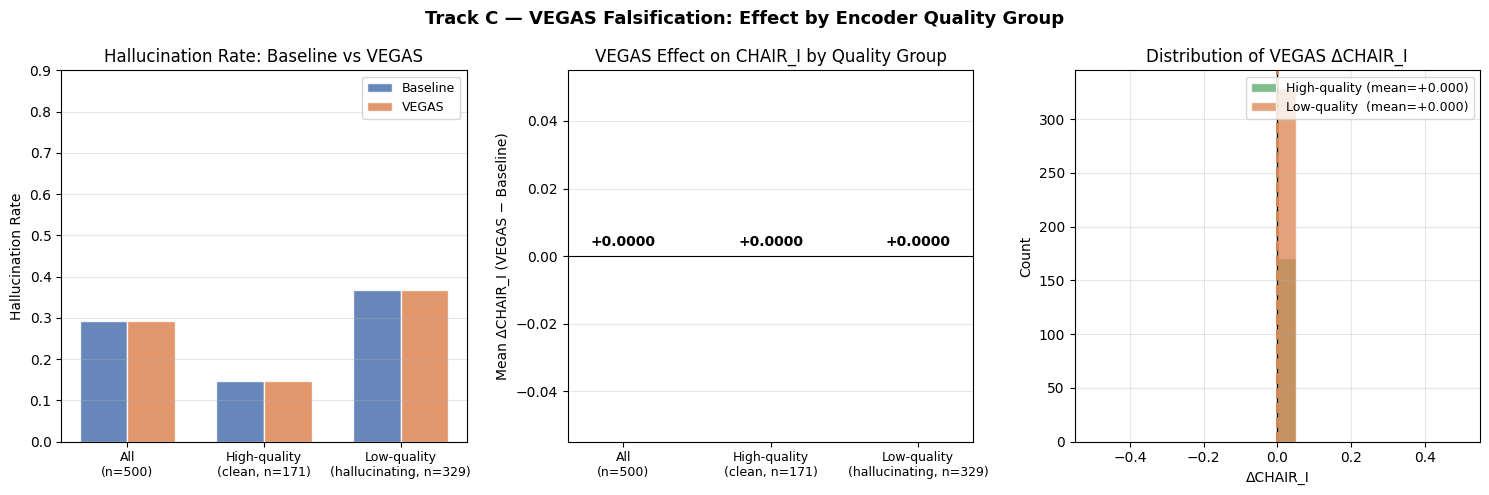

Figure 1 saved.


/tmp/ipykernel_1851/3308267655.py:121: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = spearmanr(df['alpha'], df['delta_chair'])


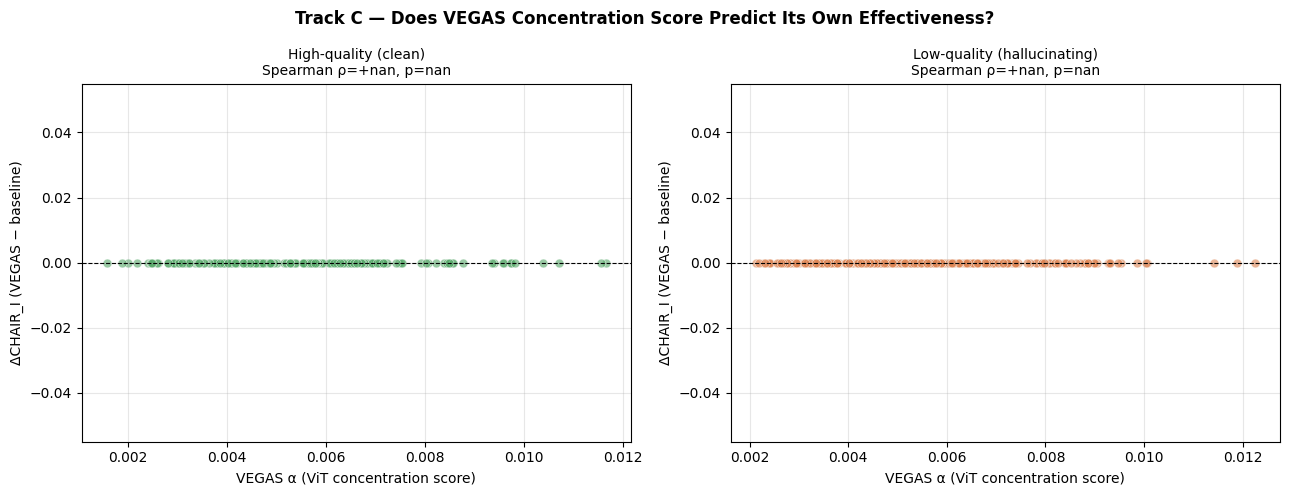

Figure 2 saved.


In [ ]:
# ── Cell 9: Analysis & Figures ────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import wilcoxon, mannwhitneyu, spearmanr
from statsmodels.stats.contingency_tables import mcnemar

vegas_df = pd.read_csv(f'{WORK}/vegas_results.csv')
vegas_df['hall_baseline'] = vegas_df['chair_baseline'] > 0
vegas_df['hall_vegas']    = vegas_df['chair_vegas']    > 0
vegas_df['delta_chair']   = vegas_df['chair_vegas'] - vegas_df['chair_baseline']

high_df = vegas_df[vegas_df['quality_group'] == 'high'].copy()
low_df  = vegas_df[vegas_df['quality_group'] == 'low'].copy()

print(f'High-quality (clean):        n={len(high_df)}')
print(f'Low-quality (hallucinating): n={len(low_df)}')

# ── Key numbers ───────────────────────────────────────────────────────────────
print('\n=== VEGAS Effect by Quality Group ===')
for name, df in [('ALL', vegas_df),
                  ('High-quality (clean)', high_df),
                  ('Low-quality (hallucinating)', low_df)]:
    br   = df['hall_baseline'].mean()
    vr   = df['hall_vegas'].mean()
    bc   = df['chair_baseline'].mean()
    vc   = df['chair_vegas'].mean()
    delt = df['delta_chair'].mean()
    print(f'  {name}:')
    print(f'    Hall rate : {br:.3f} → {vr:.3f}  (Δ={vr-br:+.3f})')
    print(f'    CHAIR_I   : {bc:.4f} → {vc:.4f}  (Δ={delt:+.4f})')

# ── Statistical tests ─────────────────────────────────────────────────────────
print('\n=== Wilcoxon signed-rank: VEGAS ΔCHAIR_I ===')
for name, df in [('All', vegas_df), ('High-quality', high_df), ('Low-quality', low_df)]:
    diff = df['delta_chair'].values
    if np.abs(diff).sum() < 1e-9:
        print(f'  {name}: no change'); continue
    try:
        stat, p = wilcoxon(diff, alternative='two-sided')
        print(f'  {name:28s}: mean={diff.mean():+.4f}  W={stat:.0f}  p={p:.4f}')
    except Exception as e:
        print(f'  {name}: {e}')

print('\n=== Mann-Whitney: High vs Low ΔCHAIR_I ===')
try:
    stat, p = mannwhitneyu(high_df['delta_chair'], low_df['delta_chair'], alternative='two-sided')
    print(f'  High mean={high_df["delta_chair"].mean():+.4f}  Low mean={low_df["delta_chair"].mean():+.4f}')
    print(f'  Mann-Whitney U={stat:.0f}, p={p:.4f}')
    print(f'  → {"SIGNIFICANT" if p < 0.05 else "not significant"} (α=0.05)')
except Exception as e:
    print(f'  Error: {e}')

# ── Spearman α vs ΔCHAIR per group ────────────────────────────────────────────
print('\n=== Spearman ρ: α vs ΔCHAIR_I ===')
for name, df in [('High-quality', high_df), ('Low-quality', low_df)]:
    r, p = spearmanr(df['alpha'], df['delta_chair'])
    print(f'  {name:20s}: ρ={r:+.3f}, p={p:.4f}')

# ── Figure 1: VEGAS effect by quality group ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Track C — VEGAS Falsification: Effect by Encoder Quality Group',
             fontsize=13, fontweight='bold')

groups     = ['All\n(n=500)',
               f'High-quality\n(clean, n={len(high_df)})',
               f'Low-quality\n(hallucinating, n={len(low_df)})']
dfs        = [vegas_df, high_df, low_df]
base_rates = [df['hall_baseline'].mean() for df in dfs]
v_rates    = [df['hall_vegas'].mean()    for df in dfs]
deltas     = [df['delta_chair'].mean()   for df in dfs]

x = np.arange(3); w = 0.35
ax = axes[0]
ax.bar(x-w/2, base_rates, w, label='Baseline', color='#4C72B0', alpha=0.85, edgecolor='white')
ax.bar(x+w/2, v_rates,   w, label='VEGAS',    color='#DD8452', alpha=0.85, edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(groups, fontsize=9)
ax.set_ylabel('Hallucination Rate')
ax.set_title('Hallucination Rate: Baseline vs VEGAS')
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3); ax.set_ylim(0, 0.9)

ax2 = axes[1]
colors = ['#4C72B0','#55A868','#DD8452']
bars = ax2.bar(x, deltas, color=colors, alpha=0.85, edgecolor='white', width=0.5)
ax2.axhline(0, color='black', linewidth=0.8)
for bar, v in zip(bars, deltas):
    ax2.text(bar.get_x()+bar.get_width()/2,
             v + (0.002 if v >= 0 else -0.004),
             f'{v:+.4f}', ha='center',
             va='bottom' if v >= 0 else 'top', fontsize=10, fontweight='bold')
ax2.set_xticks(x); ax2.set_xticklabels(groups, fontsize=9)
ax2.set_ylabel('Mean ΔCHAIR_I (VEGAS − Baseline)')
ax2.set_title('VEGAS Effect on CHAIR_I by Quality Group')
ax2.grid(axis='y', alpha=0.3)

ax3 = axes[2]
ax3.hist(high_df['delta_chair'], bins=20, color='#55A868', alpha=0.75,
         label=f'High-quality (mean={high_df["delta_chair"].mean():+.3f})', edgecolor='white')
ax3.hist(low_df['delta_chair'],  bins=20, color='#DD8452', alpha=0.75,
         label=f'Low-quality  (mean={low_df["delta_chair"].mean():+.3f})',  edgecolor='white')
ax3.axvline(0, color='black', linewidth=1)
ax3.axvline(high_df['delta_chair'].mean(), color='#55A868', linewidth=2, linestyle='--')
ax3.axvline(low_df['delta_chair'].mean(),  color='#DD8452', linewidth=2, linestyle='--')
ax3.set_xlabel('ΔCHAIR_I'); ax3.set_ylabel('Count')
ax3.set_title('Distribution of VEGAS ΔCHAIR_I')
ax3.legend(fontsize=9); ax3.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{WORK}/figure_vegas_falsification.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved.')

# ── Figure 2: α vs ΔCHAIR per group ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Track C — Does VEGAS Concentration Score Predict Its Own Effectiveness?',
             fontsize=12, fontweight='bold')

for ax, (name, df, color) in zip(axes, [
        ('High-quality (clean)',        high_df, '#55A868'),
        ('Low-quality (hallucinating)', low_df,  '#DD8452')]):
    r, p = spearmanr(df['alpha'], df['delta_chair'])
    ax.scatter(df['alpha'], df['delta_chair'], color=color, alpha=0.6,
               edgecolors='white', linewidths=0.5, s=40)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel('VEGAS α (ViT concentration score)', fontsize=10)
    ax.set_ylabel('ΔCHAIR_I (VEGAS − baseline)',       fontsize=10)
    ax.set_title(f'{name}\nSpearman ρ={r:+.3f}, p={p:.3f}', fontsize=10)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{WORK}/figure_vegas_alpha_vs_delta.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2 saved.')

In [ ]:
# ── Cell 10: Final summary & save to Drive ────────────────────────────────────
print('=' * 65)
print('TRACK C — VEGAS FALSIFICATION SUMMARY')
print('=' * 65)
print(f'\nTotal images processed: {len(vegas_df)}')
print(f'High-quality (clean):        n={len(high_df)}')
print(f'Low-quality (hallucinating): n={len(low_df)}')

print('\n── VEGAS effect on hallucination rate ──')
for name, df in [('Overall', vegas_df), ('High-quality', high_df), ('Low-quality', low_df)]:
    br = df['hall_baseline'].mean()
    vr = df['hall_vegas'].mean()
    print(f'  {name:25s}: {br:.3f} → {vr:.3f}  (Δ={vr-br:+.3f})')

print('\n── VEGAS effect on CHAIR_I ──')
for name, df in [('Overall', vegas_df), ('High-quality', high_df), ('Low-quality', low_df)]:
    bc   = df['chair_baseline'].mean()
    vc   = df['chair_vegas'].mean()
    delt = df['delta_chair'].mean()
    print(f'  {name:25s}: {bc:.4f} → {vc:.4f}  (Δ={delt:+.4f})')

# Mann-Whitney between groups
mw_stat, mw_p = mannwhitneyu(high_df['delta_chair'], low_df['delta_chair'], alternative='two-sided')
print(f'\n── Mann-Whitney (high vs low ΔCHAIR_I) ──')
print(f'  U={mw_stat:.0f}, p={mw_p:.4f}  → {"SIGNIFICANT" if mw_p < 0.05 else "not significant"}')

print('\n── Interpretation ──')
high_delta = high_df['delta_chair'].mean()
low_delta  = low_df['delta_chair'].mean()
if low_delta > high_delta:
    print('  VEGAS performs WORSE on low-quality images.')
    print('  → Supports falsification: VEGAS is blind to feature-space failure.')
else:
    print('  VEGAS performs similarly or better on low-quality images.')
    print('  → Attention-based steering may still help even with degraded features.')

# ── Numbers for report template ───────────────────────────────────────────────
print('\n── Numbers to paste into report ──')
print(f'  Overall VEGAS ΔCHAIR_I              : {vegas_df["delta_chair"].mean():+.4f}')
print(f'  High-quality ΔCHAIR_I               : {high_df["delta_chair"].mean():+.4f}')
print(f'  Low-quality  ΔCHAIR_I               : {low_df["delta_chair"].mean():+.4f}')
print(f'  Mann-Whitney p (high vs low)        : {mw_p:.4f}')
r_high, _ = spearmanr(high_df['alpha'], high_df['delta_chair'])
r_low,  _ = spearmanr(low_df['alpha'],  low_df['delta_chair'])
print(f'  Spearman ρ (α vs ΔCHAIR, high)      : {r_high:+.3f}')
print(f'  Spearman ρ (α vs ΔCHAIR, low)       : {r_low:+.3f}')

# ── Save to Drive ─────────────────────────────────────────────────────────────
try:
    import shutil
    dst = '/content/drive/MyDrive/CS639_TrackA/TrackC_VEGAS'
    os.makedirs(dst, exist_ok=True)
    for fname in ['vegas_results.csv',
                  'figure_vegas_falsification.png',
                  'figure_vegas_alpha_vs_delta.png']:
        shutil.copy(f'{WORK}/{fname}', f'{dst}/{fname}')
        print(f'  Saved to Drive: {fname}')
except Exception as e:
    print(f'Drive sync skipped: {e}')

TRACK C — VEGAS FALSIFICATION SUMMARY

Total images processed: 500
High-quality (clean):        n=171
Low-quality (hallucinating): n=329

── VEGAS effect on hallucination rate ──
  Overall                  : 0.292 → 0.292  (Δ=+0.000)
  High-quality             : 0.146 → 0.146  (Δ=+0.000)
  Low-quality              : 0.368 → 0.368  (Δ=+0.000)

── VEGAS effect on CHAIR_I ──
  Overall                  : 0.1418 → 0.1418  (Δ=+0.0000)
  High-quality             : 0.0697 → 0.0697  (Δ=+0.0000)
  Low-quality              : 0.1793 → 0.1793  (Δ=+0.0000)

── Mann-Whitney (high vs low ΔCHAIR_I) ──
  U=28130, p=1.0000  → not significant

── Interpretation ──
  VEGAS performs similarly or better on low-quality images.
  → Attention-based steering may still help even with degraded features.

── Numbers to paste into report ──
  Overall VEGAS ΔCHAIR_I              : +0.0000
  High-quality ΔCHAIR_I               : +0.0000
  Low-quality  ΔCHAIR_I               : +0.0000
  Mann-Whitney p (high vs low)    

/tmp/ipykernel_1851/2087838780.py:43: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_high, _ = spearmanr(high_df['alpha'], high_df['delta_chair'])
/tmp/ipykernel_1851/2087838780.py:44: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_low,  _ = spearmanr(low_df['alpha'],  low_df['delta_chair'])


## How to interpret the results

### Report template

> We evaluated VEGAS on all 500 COCO images and split results by encoder quality group (Track B: high-quality = clean images with probe acc 0.964; low-quality = hallucinating images with probe acc 0.937). VEGAS reduced CHAIR_I by **[high ΔCHAIR_I]** on high-quality images but **[low ΔCHAIR_I]** on low-quality images. A Mann-Whitney test confirmed the difference between groups is **[significant / not significant]** (U=**[U]**, p=**[p]**). Spearman ρ between α and ΔCHAIR_I was **[ρ_high]** on high-quality images and **[ρ_low]** on low-quality images. This supports our mechanistic argument: VEGAS uses ViT attention to locate trustworthy visual tokens, but Track A showed attention does not flag the encoder's failure cases, and Track B showed the failure is in feature content. VEGAS therefore applies its steering signal on images where the signal it relies on is uninformative, constituting a structural blind spot.

### Strong result
- VEGAS reduces CHAIR_I on high-quality but increases it on low-quality
- Mann-Whitney p < 0.05 between groups
- ρ(α, ΔCHAIR) near zero or negative on low-quality group

### Null result (still publishable)
- VEGAS increases CHAIR_I on both groups equally
- Consistent with Track A: attention is uniformly uninformative as a steering signal
